In [1]:
import json
import ast
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from datasets import load_dataset
from sklearn.metrics import roc_auc_score
from sklearn.linear_model import LogisticRegression

In [2]:
traj_ds = load_dataset("SWE-bench/SWE-smith-trajectories", split="tool")

smith_ds = load_dataset("SWE-bench/SWE-smith-py", split="train")

README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00011.parquet:   0%|          | 0.00/16.9M [00:00<?, ?B/s]

data/train-00001-of-00011.parquet:   0%|          | 0.00/5.57M [00:00<?, ?B/s]

data/train-00002-of-00011.parquet:   0%|          | 0.00/6.01M [00:00<?, ?B/s]

data/train-00003-of-00011.parquet:   0%|          | 0.00/118M [00:00<?, ?B/s]

...

data/train-00007-of-00011.parquet:   0%|          | 0.00/6.67M [00:00<?, ?B/s]

data/train-00008-of-00011.parquet:   0%|          | 0.00/21.7M [00:00<?, ?B/s]

data/train-00009-of-00011.parquet:   0%|          | 0.00/7.64M [00:00<?, ?B/s]

data/train-00010-of-00011.parquet:   0%|          | 0.00/9.08M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50908 [00:00<?, ? examples/s]

In [3]:
traj_df = traj_ds.to_pandas()
smith_df = smith_ds.to_pandas()

print("traj_df shape:", traj_df.shape)
print("smith_df shape:", smith_df.shape)

print("\ntraj columns:")
print(traj_df.columns.tolist())

print("\nsmith columns:")
print(smith_df.columns.tolist())

traj_df shape: (24100, 6)
smith_df shape: (50908, 7)

traj columns:
['messages', 'instance_id', 'resolved', 'model', 'traj_id', 'patch']

smith columns:
['instance_id', 'patch', 'FAIL_TO_PASS', 'PASS_TO_PASS', 'image_name', 'repo', 'problem_statement']


In [8]:
def is_empty_patch(x):
    if pd.isna(x):
        return True
    s = str(x).strip()
    if s == "":
        return True
    if s.lower() in {"nan", "none", "null"}:
        return True
    return False

traj_df["patch_is_empty"] = traj_df["patch"].apply(is_empty_patch)

print("Empty patch count:", traj_df["patch_is_empty"].sum())
print("Empty patch ratio:", traj_df["patch_is_empty"].mean())

traj_df = traj_df.loc[~traj_df["patch_is_empty"]].copy()

print("Filtered traj_df shape:", traj_df.shape)

Empty patch count: 5944
Empty patch ratio: 0.2466390041493776
Filtered traj_df shape: (18156, 7)


In [9]:
# distinct instance_id
traj_ids = set(traj_df["instance_id"].dropna().astype(str))
smith_ids = set(smith_df["instance_id"].dropna().astype(str))

intersection_ids = traj_ids & smith_ids
traj_only_ids = traj_ids - smith_ids
smith_only_ids = smith_ids - traj_ids

print("Unique traj instance_id:", len(traj_ids))
print("Unique smith instance_id:", len(smith_ids))
print("Intersection:", len(intersection_ids))
print("traj only:", len(traj_only_ids))
print("smith only:", len(smith_only_ids))

coverage = len(intersection_ids) / len(traj_ids) if len(traj_ids) > 0 else 0
print(f"\nCoverage of traj by smith: {coverage:.4f}")

Unique traj instance_id: 8541
Unique smith instance_id: 50908
Intersection: 7899
traj only: 642
smith only: 43009

Coverage of traj by smith: 0.9248


In [10]:
# 检查每个表中 instance_id 是否唯一
traj_id_counts = traj_df["instance_id"].astype(str).value_counts()
smith_id_counts = smith_df["instance_id"].astype(str).value_counts()

print("Trajectory duplicated instance_id count:", (traj_id_counts > 1).sum())
print("Smith duplicated instance_id count:", (smith_id_counts > 1).sum())

print("\nTop duplicated traj instance_id:")
print(traj_id_counts[traj_id_counts > 1].head(10))

print("\nTop duplicated smith instance_id:")
print(smith_id_counts[smith_id_counts > 1].head(10))

Trajectory duplicated instance_id count: 3985
Smith duplicated instance_id count: 0

Top duplicated traj instance_id:
instance_id
Project-MONAI__MONAI.a09c1f08.pr_5423    17
pydantic__pydantic.acb0f10f.pr_8316      16
Project-MONAI__MONAI.a09c1f08.pr_4775    16
python__mypy.e93f06ce.pr_12943           15
getmoto__moto.694ce1f4.pr_5321           15
pandas-dev__pandas.95280573.pr_53856     14
iterative__dvc.1d6ea681.pr_5839          14
getmoto__moto.694ce1f4.pr_6913           14
pydantic__pydantic.acb0f10f.pr_8567      14
dask__dask.5f61e423.pr_6911              14
Name: count, dtype: int64

Top duplicated smith instance_id:
Series([], Name: count, dtype: int64)


In [11]:
print(traj_df["resolved"].value_counts(dropna=False))
print(traj_df["resolved"].dtype)

resolved
False    11011
True      7145
Name: count, dtype: int64
bool


In [12]:
merged_df = traj_df.merge(
    smith_df,
    on="instance_id",
    how="left",
    suffixes=("_traj", "_smith")
)

print("merged_df shape:", merged_df.shape)
print("Rows with missing smith match:", merged_df["repo"].isna().sum())

merged_df shape: (18156, 13)
Rows with missing smith match: 966


In [13]:
print(merged_df.columns.tolist())

['messages', 'instance_id', 'resolved', 'model', 'traj_id', 'patch_traj', 'patch_is_empty', 'patch_smith', 'FAIL_TO_PASS', 'PASS_TO_PASS', 'image_name', 'repo', 'problem_statement']


In [14]:
analysis_df = merged_df.loc[merged_df["repo"].notna()].copy()

print("analysis_df shape:", analysis_df.shape)
print("Dropped unmatched rows:", len(merged_df) - len(analysis_df))

analysis_df shape: (17190, 13)
Dropped unmatched rows: 966


In [33]:
import numpy as np
import pandas as pd
import re

def is_sequence_like(x):
    return isinstance(x, (list, tuple, np.ndarray))

def to_py_list(x):
    if x is None:
        return []
    if isinstance(x, np.ndarray):
        return x.tolist()
    if isinstance(x, (list, tuple)):
        return list(x)
    if isinstance(x, float) and np.isnan(x):
        return []
    return []

def seq_len(x):
    if x is None:
        return 0
    if is_sequence_like(x):
        return len(x)
    if isinstance(x, float) and np.isnan(x):
        return 0
    return 0

def unique_len(x):
    if x is None:
        return 0
    if is_sequence_like(x):
        return len(set(map(str, x)))
    if isinstance(x, float) and np.isnan(x):
        return 0
    return 0

def extract_test_scope(test_name: str):
    if not isinstance(test_name, str):
        return None
    s = test_name.strip()
    if not s:
        return None

    if "::" in s:
        return s.split("::")[0]

    if "." in s:
        parts = s.split(".")
        if len(parts) >= 2:
            return ".".join(parts[:-1])

    return s

def count_unique_scopes(test_list):
    if not is_sequence_like(test_list):
        return 0
    scopes = [extract_test_scope(x) for x in test_list]
    scopes = [x for x in scopes if x is not None]
    return len(set(scopes))

# 先规范成 python list，后面更方便
analysis_df["ftp_list"] = analysis_df["FAIL_TO_PASS"].apply(to_py_list)
analysis_df["ptp_list"] = analysis_df["PASS_TO_PASS"].apply(to_py_list)

# 重新计算这些列
analysis_df["n_ftp"] = analysis_df["ftp_list"].apply(len)
analysis_df["n_ptp"] = analysis_df["ptp_list"].apply(len)

analysis_df["n_total_gold_tests"] = analysis_df["n_ftp"] + analysis_df["n_ptp"]

analysis_df["ftp_ptp_ratio"] = np.where(
    analysis_df["n_ptp"] > 0,
    analysis_df["n_ftp"] / analysis_df["n_ptp"],
    np.nan
)

analysis_df["n_ftp_unique"] = analysis_df["ftp_list"].apply(lambda x: len(set(map(str, x))))
analysis_df["n_ptp_unique"] = analysis_df["ptp_list"].apply(lambda x: len(set(map(str, x))))

analysis_df["ftp_scope_count"] = analysis_df["ftp_list"].apply(count_unique_scopes)
analysis_df["ptp_scope_count"] = analysis_df["ptp_list"].apply(count_unique_scopes)

In [34]:
analysis_df[[
    "FAIL_TO_PASS", "ftp_list", "n_ftp", "n_ftp_unique", "ftp_scope_count",
    "PASS_TO_PASS", "ptp_list", "n_ptp", "n_ptp_unique", "ptp_scope_count"
]].head(5)

,FAIL_TO_PASS,ftp_list,n_ftp,n_ftp_unique,ftp_scope_count,PASS_TO_PASS,ptp_list,n_ptp,n_ptp_unique,ptp_scope_count
0,[tests/test_core.py::TestPath::test_path_summa...,[tests/test_core.py::TestPath::test_path_summa...,2,2,1,[tests/test_core.py::TestAPISpecInit::test_rai...,[tests/test_core.py::TestAPISpecInit::test_rai...,567,567,7
1,[tests/test_fields.py::TestParentAndName::test...,[tests/test_fields.py::TestParentAndName::test...,5,5,1,[tests/test_decorators.py::test_decorated_proc...,[tests/test_decorators.py::test_decorated_proc...,1183,1183,12
2,[tests/test_environs.py::TestDeferredValidatio...,[tests/test_environs.py::TestDeferredValidatio...,3,3,1,[tests/test_environs.py::TestCasting::test_cal...,[tests/test_environs.py::TestCasting::test_cal...,102,102,1
3,"[test/test_wordcloud.py::test_recolor, test/te...","[test/test_wordcloud.py::test_recolor, test/te...",2,2,1,"[test/test_wordcloud.py::test_collocations, te...","[test/test_wordcloud.py::test_collocations, te...",71,71,2
4,[tests/test_extra/test_attribute.py::TestAttri...,[tests/test_extra/test_attribute.py::TestAttri...,5,5,2,"[tests/test_api.py::TestSoupSieve::test_cache,...","[tests/test_api.py::TestSoupSieve::test_cache,...",376,376,82


In [35]:
test_meta_cols = [
    "n_ftp",
    "n_ptp",
    "n_total_gold_tests",
    "ftp_ptp_ratio",
    "n_ftp_unique",
    "n_ptp_unique",
    "ftp_scope_count",
    "ptp_scope_count",
]

for col in test_meta_cols:
    print(f"\n===== {col} =====")
    print(
        analysis_df.groupby("resolved")[col]
        .describe()[["count", "mean", "50%", "std", "min", "max"]]
    )


===== n_ftp =====
            count       mean  50%         std  min     max
resolved                                                  
False     10454.0  54.431796  4.0  352.553749  1.0  7080.0
True       6736.0  78.022268  2.0  571.386238  1.0  6865.0

===== n_ptp =====
            count        mean    50%          std  min      max
resolved                                                       
False     10454.0  765.001817  149.0  1540.850460  0.0  22010.0
True       6736.0  745.140736  148.0  1549.590359  0.0  16401.0

===== n_total_gold_tests =====
            count        mean    50%          std  min      max
resolved                                                       
False     10454.0  819.433614  178.0  1581.951297  1.0  22028.0
True       6736.0  823.163005  178.0  1624.350970  1.0  16402.0

===== ftp_ptp_ratio =====
            count      mean       50%        std       min    max
resolved                                                         
False     10038.0  1.22

In [38]:
import numpy as np

for col in [
    "n_ftp",
    "n_ptp",
    "n_total_gold_tests",
    "ftp_scope_count",
    "ptp_scope_count"
]:
    analysis_df[f"log1p_{col}"] = np.log1p(analysis_df[col])

analysis_df["log1p_ftp_ptp_ratio"] = np.log1p(analysis_df["ftp_ptp_ratio"])

In [41]:
analysis_df["ftp_tests_per_file"] = np.where(
    analysis_df["ftp_file_count"] > 0,
    analysis_df["n_ftp"] / analysis_df["ftp_file_count"],
    np.nan
)

analysis_df["ptp_tests_per_file"] = np.where(
    analysis_df["ptp_file_count"] > 0,
    analysis_df["n_ptp"] / analysis_df["ptp_file_count"],
    np.nan
)

analysis_df["ftp_single_file"] = (analysis_df["ftp_file_count"] == 1).astype(int)
analysis_df["ptp_single_file"] = (analysis_df["ptp_file_count"] == 1).astype(int)

analysis_df["ftp_file_count"] = analysis_df["ftp_scope_count"]
analysis_df["ptp_file_count"] = analysis_df["ptp_scope_count"]

In [42]:
log_cols = [
    "log1p_n_ftp",
    "log1p_n_ptp",
    "log1p_n_total_gold_tests",
    "log1p_ftp_scope_count",
    "log1p_ptp_scope_count",
    "log1p_ftp_ptp_ratio",
]

for col in log_cols:
    print(f"\n===== {col} =====")
    print(
        analysis_df.groupby("resolved")[col]
        .describe()[["count", "mean", "50%", "std", "min", "max"]]
    )


===== log1p_n_ftp =====
            count      mean       50%       std       min       max
resolved                                                           
False     10454.0  1.928147  1.609438  1.392806  0.693147  8.865170
True       6736.0  1.524116  1.098612  1.306853  0.693147  8.834337

===== log1p_n_ptp =====
            count      mean       50%       std  min       max
resolved                                                      
False     10454.0  5.006466  5.010635  2.140235  0.0  9.999298
True       6736.0  5.005673  5.003946  2.114880  0.0  9.705159

===== log1p_n_total_gold_tests =====
            count      mean       50%       std       min        max
resolved                                                            
False     10454.0  5.282091  5.187386  1.884168  0.693147  10.000115
True       6736.0  5.292324  5.187386  1.853277  0.693147   9.705220

===== log1p_ftp_scope_count =====
            count     mean       50%       std       min       max
resolved  

<Figure size 600x400 with 0 Axes>

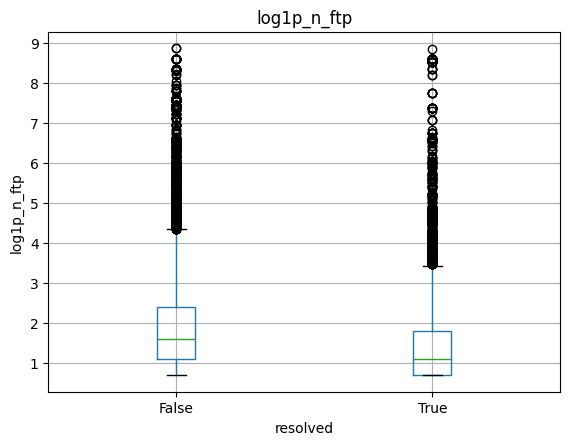

<Figure size 600x400 with 0 Axes>

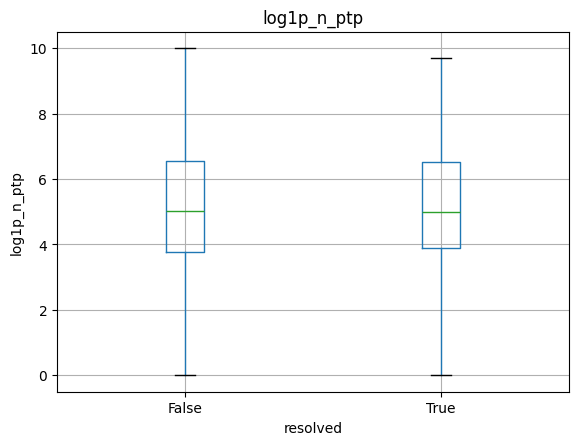

<Figure size 600x400 with 0 Axes>

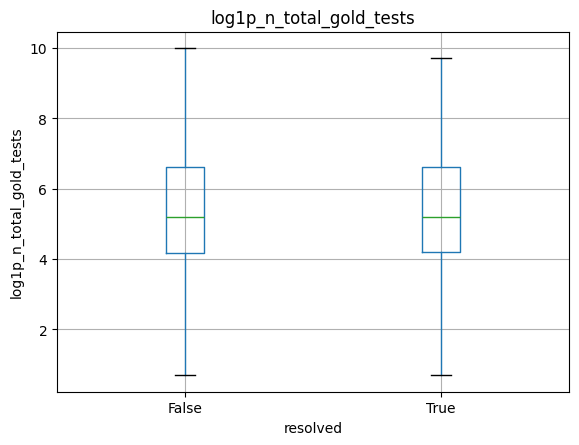

<Figure size 600x400 with 0 Axes>

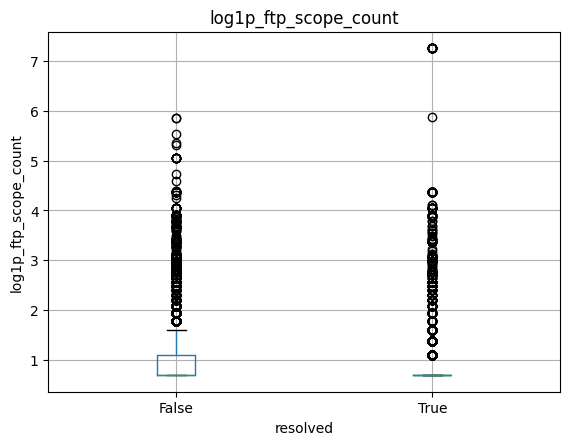

<Figure size 600x400 with 0 Axes>

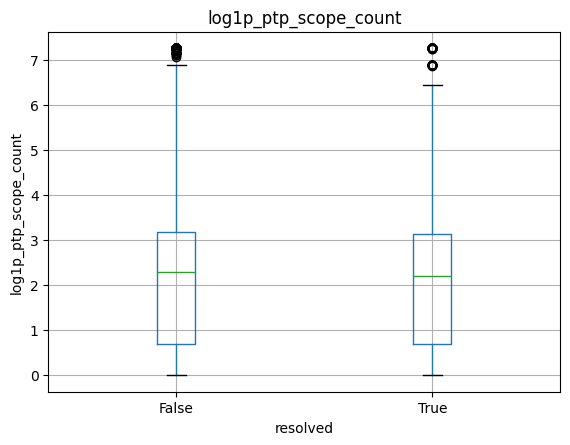

<Figure size 600x400 with 0 Axes>

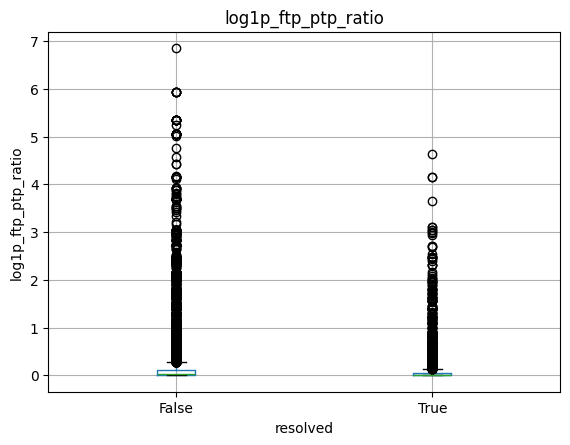

In [43]:
import matplotlib.pyplot as plt

plot_cols = [
    "log1p_n_ftp",
    "log1p_n_ptp",
    "log1p_n_total_gold_tests",
    "log1p_ftp_scope_count",
    "log1p_ptp_scope_count",
    "log1p_ftp_ptp_ratio",
]

for col in plot_cols:
    plt.figure(figsize=(6, 4))
    analysis_df.boxplot(column=col, by="resolved")
    plt.title(col)
    plt.suptitle("")
    plt.xlabel("resolved")
    plt.ylabel(col)
    plt.show()

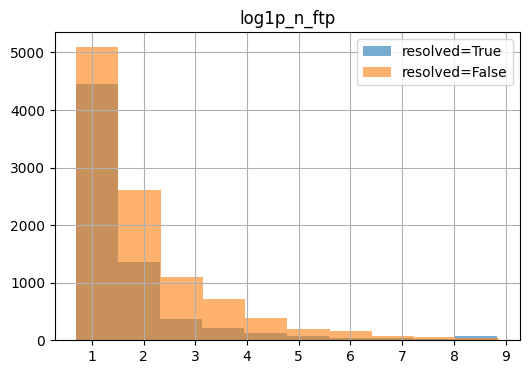

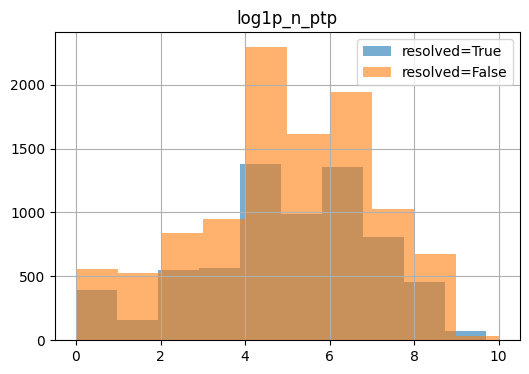

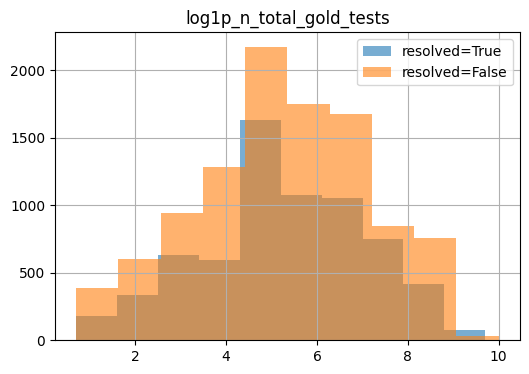

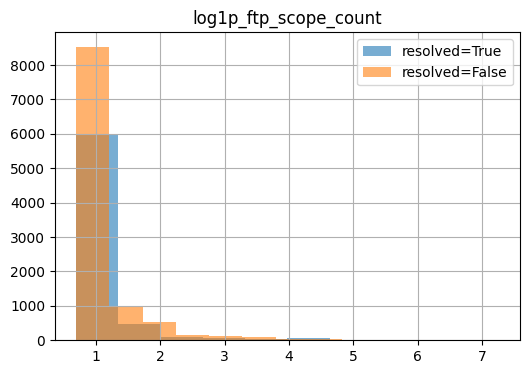

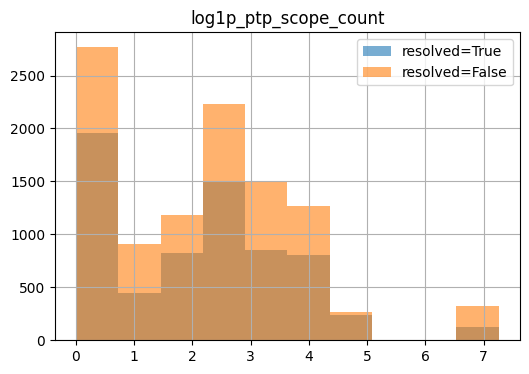

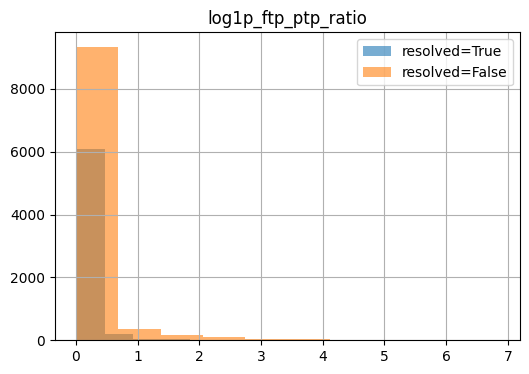

In [44]:
for col in plot_cols:
    plt.figure(figsize=(6, 4))
    analysis_df.loc[analysis_df["resolved"] == True, col].hist(alpha=0.6, label="resolved=True")
    analysis_df.loc[analysis_df["resolved"] == False, col].hist(alpha=0.6, label="resolved=False")
    plt.title(col)
    plt.legend()
    plt.show()

In [45]:
from sklearn.metrics import roc_auc_score
import numpy as np

candidate_cols = [
    "n_ftp",
    "n_ptp",
    "n_total_gold_tests",
    "ftp_ptp_ratio",
    "ftp_scope_count",
    "ptp_scope_count",
    "log1p_n_ftp",
    "log1p_n_ptp",
    "log1p_n_total_gold_tests",
    "log1p_ftp_scope_count",
    "log1p_ptp_scope_count",
    "log1p_ftp_ptp_ratio",
]

y = analysis_df["resolved"].astype(int)

for col in candidate_cols:
    x = analysis_df[col]
    valid = x.notna()
    if valid.sum() == 0 or x[valid].nunique() < 2:
        print(f"{col}: skipped")
        continue
    auc = roc_auc_score(y[valid], x[valid])
    print(f"{col}: raw AUC={auc:.4f}, symmetric AUC={max(auc, 1-auc):.4f}")

n_ftp: raw AUC=0.3857, symmetric AUC=0.6143
n_ptp: raw AUC=0.4998, symmetric AUC=0.5002
n_total_gold_tests: raw AUC=0.4994, symmetric AUC=0.5006
ftp_ptp_ratio: raw AUC=0.4177, symmetric AUC=0.5823
ftp_scope_count: raw AUC=0.4379, symmetric AUC=0.5621
ptp_scope_count: raw AUC=0.4877, symmetric AUC=0.5123
log1p_n_ftp: raw AUC=0.3857, symmetric AUC=0.6143
log1p_n_ptp: raw AUC=0.4998, symmetric AUC=0.5002
log1p_n_total_gold_tests: raw AUC=0.4994, symmetric AUC=0.5006
log1p_ftp_scope_count: raw AUC=0.4379, symmetric AUC=0.5621
log1p_ptp_scope_count: raw AUC=0.4877, symmetric AUC=0.5123
log1p_ftp_ptp_ratio: raw AUC=0.4177, symmetric AUC=0.5823


In [47]:
instance_df = (
    analysis_df.groupby("instance_id", as_index=False)
    .agg(
        repo=("repo", "first"),
        n_trajs=("traj_id", "count"),
        success_rate=("resolved", "mean"),

        n_ftp=("n_ftp", "first"),
        n_ptp=("n_ptp", "first"),
        n_total_gold_tests=("n_total_gold_tests", "first"),
        ftp_ptp_ratio=("ftp_ptp_ratio", "first"),
        ftp_file_count=("ftp_scope_count", "first"),
        ptp_file_count=("ptp_scope_count", "first"),
    )
)

In [48]:
instance_df[[
    "success_rate",
    "n_ftp",
    "n_ptp",
    "n_total_gold_tests",
    "ftp_ptp_ratio",
    "ftp_file_count",
    "ptp_file_count",
]].corr(numeric_only=True)["success_rate"].sort_values()

ftp_ptp_ratio        -0.038847
ptp_file_count       -0.035562
n_ptp                -0.008404
n_total_gold_tests   -0.003181
n_ftp                 0.015804
ftp_file_count        0.037501
success_rate          1.000000
Name: success_rate, dtype: float64

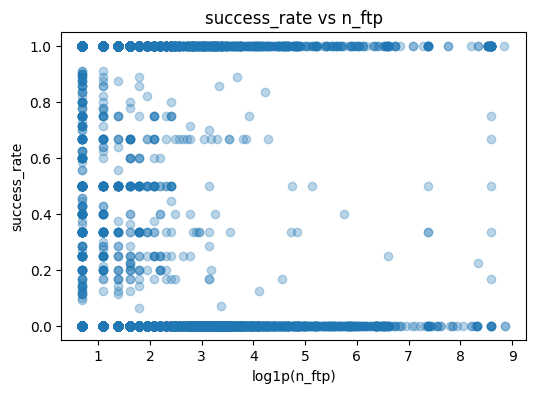

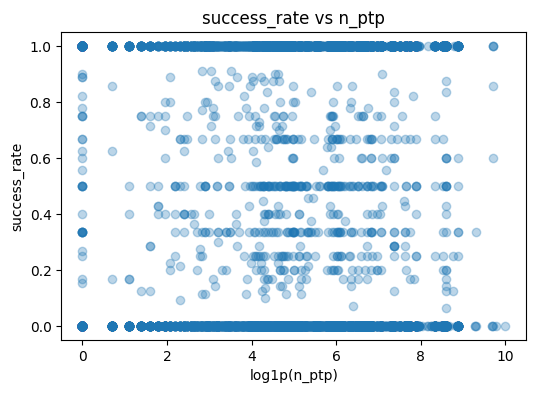

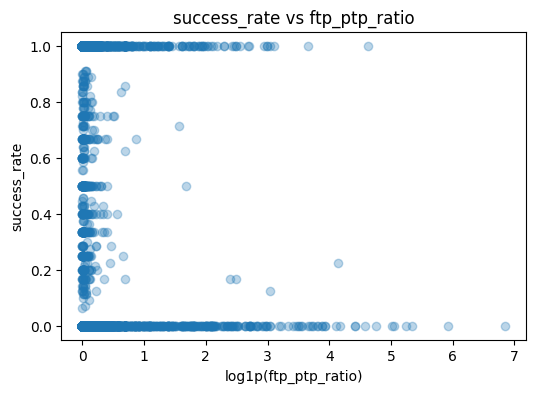

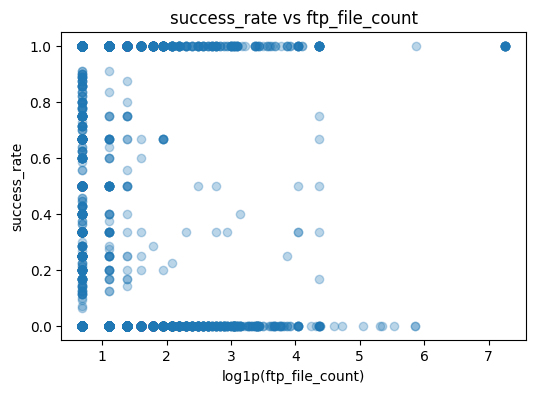

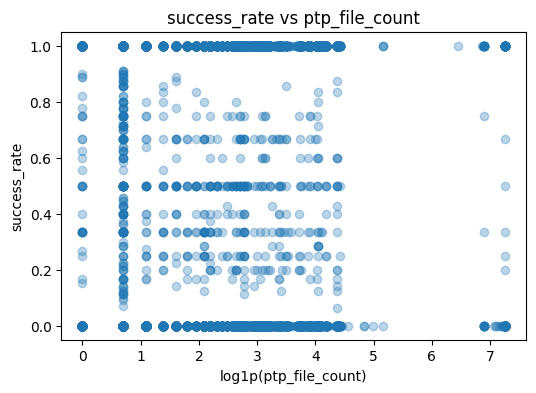

In [49]:
import matplotlib.pyplot as plt
import numpy as np

for col in ["n_ftp", "n_ptp", "ftp_ptp_ratio", "ftp_file_count", "ptp_file_count"]:
    plt.figure(figsize=(6,4))
    plt.scatter(np.log1p(instance_df[col]), instance_df["success_rate"], alpha=0.3)
    plt.xlabel(f"log1p({col})")
    plt.ylabel("success_rate")
    plt.title(f"success_rate vs {col}")
    plt.show()

In [51]:
instance_df_any = (
    analysis_df.groupby("instance_id", as_index=False)
    .agg(
        repo=("repo", "first"),
        n_trajs=("traj_id", "count"),
        any_success=("resolved", "max"),

        n_ftp=("n_ftp", "first"),
        n_ptp=("n_ptp", "first"),
        n_total_gold_tests=("n_total_gold_tests", "first"),
        ftp_ptp_ratio=("ftp_ptp_ratio", "first"),
        ftp_file_count=("ftp_scope_count", "first"),
        ptp_file_count=("ptp_scope_count", "first"),
    )
)

instance_df[[
    "success_rate",
    "n_ftp",
    "n_ptp",
    "n_total_gold_tests",
    "ftp_ptp_ratio",
    "ftp_file_count",
    "ptp_file_count",
]].corr(numeric_only=True)["success_rate"].sort_values()

ftp_ptp_ratio        -0.038847
ptp_file_count       -0.035562
n_ptp                -0.008404
n_total_gold_tests   -0.003181
n_ftp                 0.015804
ftp_file_count        0.037501
success_rate          1.000000
Name: success_rate, dtype: float64

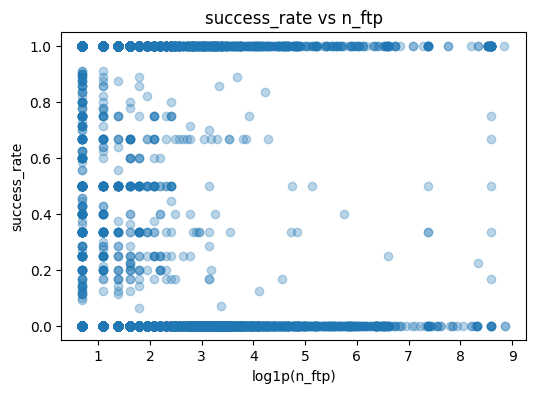

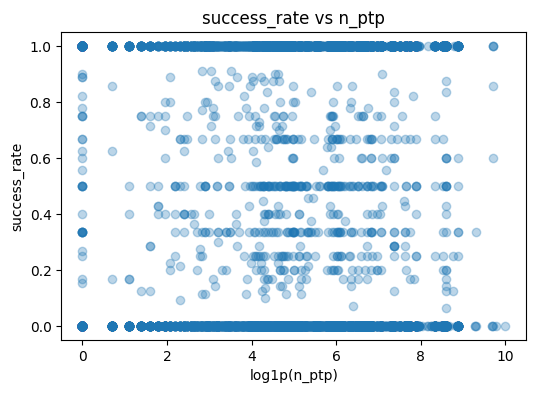

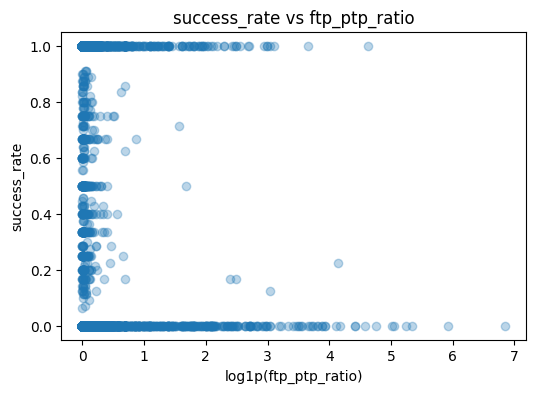

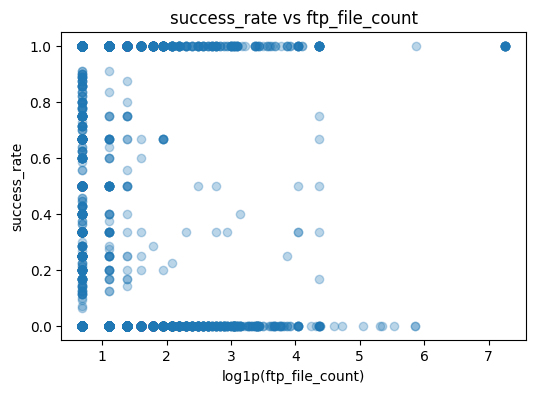

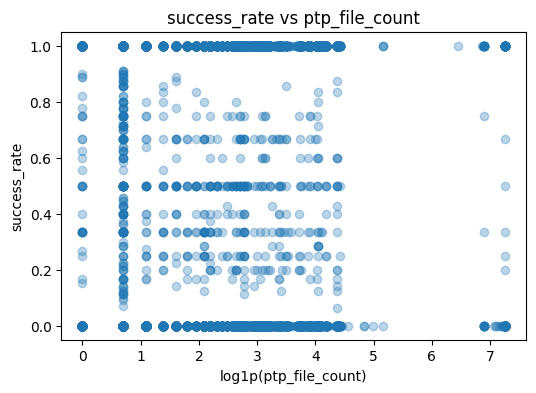

In [52]:
for col in ["n_ftp", "n_ptp", "ftp_ptp_ratio", "ftp_file_count", "ptp_file_count"]:
    plt.figure(figsize=(6,4))
    plt.scatter(np.log1p(instance_df[col]), instance_df["success_rate"], alpha=0.3)
    plt.xlabel(f"log1p({col})")
    plt.ylabel("success_rate")
    plt.title(f"success_rate vs {col}")
    plt.show()